# **Comparative Analysis of Bipartite Networks**

# Import Libraries and Configurations

In [1]:
import os
import sys
from itertools import combinations, permutations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib_venn import venn2, venn3
from venn import venn

# Add project root to Python's path
sys.path.append(os.path.abspath(os.path.join('..')))

from config import (
    DATA_SUBDIRS,
    NETWORK_DATA_DIRS,
)

# Remove the HER2-enriched group from the analysis
GROUPS = DATA_SUBDIRS.copy()
GROUPS.remove('her2-enriched')

# Define the possible types of bipartite networks
NETWORK_TYPES = ('interaction', 'membership')

# Metrics calculated in the individual analysis
METRICS = [
    # 'degree', 
    'betweenness_centrality', 
    'closeness_centrality', 
    'degree_centrality', 
    'redundancy_coefficient', 
]

# Thresholds for node classification
LOWER_NODE_RANKING_THRESHOLD = 0.25
UPPER_NODE_RANKING_THRESHOLD = 0.50
JACCARD_NODE_RANKING_THRESHOLD = 0.25

# Functions

## Venn Diagram Plot

### Plot Venn Diagram

In [2]:
def plot_venn_diagram(df_elements, network_type, partition=None):
    # Create a dictionary to store the sets by group
    sets = dict()

    # Define the base title of the plot
    plot_title = f'{network_type.capitalize()} Networks'

    # Check if the DataFrame is a list of nodes or edges
    if partition:
        # Preparing to handle a list of nodes
        df_elements = df_elements.query('type == @partition')
        plot_title = f'{plot_title} - {partition} Nodes'
        column_of_interest = 'id'
    else:
        # Preparing to handle a list of edges
        df_elements['pair'] = (
            df_elements['source'] + '_' + df_elements['target']
        )
        plot_title = f'{plot_title} - Edges'
        column_of_interest = 'pair'

    # Iterate over the groups
    groups = df_elements['group'].unique()
    for group in groups:
        # Select the elements related to the group
        elements = df_elements \
            .query('group == @group') \
            [column_of_interest].to_list()

        # Store the set of elements in the dictionary
        sets[group] = set(elements)

    # Create the diagram according to the number of sets
    subsets = list(sets.values())
    set_labels = list(sets.keys())
    if len(groups) == 2:
        venn2(subsets=subsets, set_labels=set_labels)
    elif len(groups) == 3:
        venn3(subsets=subsets, set_labels=set_labels)
    else:
        venn(sets)

    # Plot the Venn diagram
    plt.title(plot_title)
    plt.show()

    return sets

### Plot the Node Diagram

In [3]:
def plot_nodes_venn_diagram(analyzed_networks):
    # Create a dictionary to store the sets of nodes
    node_sets = dict()

    # Iterate over the network types
    for network_type in NETWORK_TYPES:
        # Initialize the network type dictionary
        node_sets[network_type] = dict()

        # Define the list of nodes for the network type
        df_nodes = \
            analyzed_networks[network_type]['nodes'].copy()

        # Iterate over the partitions
        partitions = df_nodes['type'].unique()
        for partition in partitions:
            # Plot the Venn diagram
            partition_sets = plot_venn_diagram(
                df_elements=df_nodes, 
                network_type=network_type, 
                partition=partition,
            )

            # Store the sets of nodes related to the partition
            node_sets[network_type][partition] = partition_sets
    
    return node_sets

### Plot the Edge Diagram

In [4]:
def plot_edges_venn_diagram(analyzed_networks):
    # Create a dictionary to store the sets of edges
    edge_sets = dict()

    # Iterate over the network types
    for network_type in NETWORK_TYPES:
        # Define the list of edges for the network type
        df_edges = \
            analyzed_networks[network_type]['edges'].copy()

        # Plot the Venn diagram
        network_sets = plot_venn_diagram(
            df_elements=df_edges, 
            network_type=network_type, 
        )

        # Store the sets of edges related to the network type
        edge_sets[network_type] = network_sets
    
    return edge_sets

## Operations Between Sets

### Print the Intersection Elements

In [5]:
def print_intersection_elements(sets, network_type, partition=None):
    # Select the sets of elements related to the network type
    network_sets = sets[network_type]
    title = f'{network_type.capitalize()} Networks'

    # Check if the sets are of nodes or edges
    if partition:
        # Preparing to handle node sets
        network_sets = network_sets[partition]
        subtypes = list(network_sets.keys())
        title = f'{title} - {partition} Nodes'
    else:
        # Preparing to handle edge sets
        subtypes = list(network_sets.keys())
        title = f'{title} - Edges'

    print(f'===== {title} =====')

    # Print the intersections between three sets, if necessary
    if len(subtypes) == 3:
        print('\n##### 3-Set Intersections #####')
        for s1, s2, s3 in combinations(subtypes, 3):
            # Select each of the sets
            set1 = set(network_sets[s1])
            set2 = set(network_sets[s2])
            set3 = set(network_sets[s3])

            # Compute the intersection
            inter = set1 & set2 & set3
            print(f'\n> {s1} ∩ {s2} ∩ {s3} = {len(inter)}')

            # Print the elements at the intersection
            for edge in sorted(inter):
                print(edge.split('_'))
    
    # Print the intersections between two sets
    print('\n##### 2-Set Intersections #####')
    for s1, s2 in combinations(subtypes, 2):
        # Select each of the sets
        set1 = set(network_sets[s1])
        set2 = set(network_sets[s2])

        # Compute the intersection
        inter = set1 & set2
        print(f'\n> {s1} ∩ {s2} = {len(inter)}')

        # Print the elements at the intersection
        for edge in sorted(inter):
            print(edge.split('_'))

### Print the Difference Elements

In [6]:
def print_different_elements(sets, network_type, partition=None):
    # Select the sets of elements related to the network type
    network_sets = sets[network_type]
    title = f'{network_type.capitalize()} Networks'

    # Check if the sets are of nodes or edges
    if partition:
        # Preparing to handle node sets
        network_sets = network_sets[partition]
        subtypes = list(network_sets.keys())
        title = f'{title} - {partition} Nodes'
    else:
        # Preparing to handle edge sets
        subtypes = list(network_sets.keys())
        title = f'{title} - Edges'

    print(f'===== {title} =====')

    # Print the differences between three sets, if necessary
    if len(subtypes) == 3:
        print('\n##### 3-Set Differences #####')
        for s1 in subtypes:
            remaining = [s for s in subtypes if s != s1]
            for s2, s3 in combinations(remaining, 2):
                # Select each of the sets
                set1 = set(network_sets[s1])
                set2 = set(network_sets[s2])
                set3 = set(network_sets[s3])

                # Compute the difference
                diff = set1 - (set2 | set3)
                print(f'\n> {s1} - ({s2} ∪ {s3}) = {len(diff)}')

                # Print the elements of the difference
                for edge in sorted(diff):
                    print(edge.split('_'))

    # Print the differences between the sets
    print('\n##### 2-Set Differences #####')
    for s1, s2 in permutations(subtypes, 2):
        # Select each of the sets
        set1 = set(network_sets[s1])
        set2 = set(network_sets[s2])

        # Compute the difference
        diff = set1 - set2
        print(f'\n> {s1} - {s2} = {len(diff)}')

        # Print the elements of the difference
        for edge in sorted(diff):
            print(edge.split('_'))

### Print the Resulting Nodes

In [7]:
def print_resulting_nodes(node_sets, operation):
    # Iterate over the network types
    for network_type in NETWORK_TYPES:
        # Select the network partitions
        partitions = list(node_sets[network_type].keys())

        # Iterate over the partitions
        for partition in partitions:
            # Print the elements at the intersections
            if operation == 'intersection':
                print_intersection_elements(
                    sets=node_sets,
                    network_type=network_type,
                    partition=partition,
                )
            # Print the elements of the differences
            elif operation == 'difference':
                print_different_elements(
                    sets=node_sets,
                    network_type=network_type,
                    partition=partition,
                )
            
            print()

### Print the Resulting Edges

In [8]:
def print_resulting_edges(edge_sets, operation):
    # Iterate over the network types
    for network_type in NETWORK_TYPES:
        # Print the elements at the intersections
        if operation == 'intersection':
            print_intersection_elements(
                sets=edge_sets,
                network_type=network_type,
            )
        # Print the elements of the differences
        elif operation == 'difference':
            print_different_elements(
                sets=edge_sets,
                network_type=network_type,
            )
        
        print()

## Classification of Node Specificity

### Rank Nodes by Metric Values

In [9]:
def rank_nodes_by_metric_values(
    df_nodes, partition, metric, ascending_order=False
):
    # Create a dictionary to store ranked lists of nodes
    ranked_nodes = dict()

    # Iterate over the groups
    groups = df_nodes['group'].unique()
    for group in groups:
        # Sort the nodes according to their metric values
        df_metric_ranked = df_nodes \
            .query('(group == @group) and (type == @partition)') \
            .dropna(subset=metric) \
            .sort_values(by=metric, ascending=ascending_order)
        
        # Store the ranked list of nodes on the dictionary
        ranked_nodes[group] = df_metric_ranked['id'].to_list()
    
    return ranked_nodes

### Classify the Specificity of the Nodes

In [10]:
def classify_node_specifity(ranked_nodes):
    # Create dictionaries to store specific and non-specific nodes
    specific = dict()
    non_specific = dict()

    # Iterate over the groups
    groups = ranked_nodes.keys()
    for group1 in groups:
        # Select the ranked nodes related to the group
        group1_nodes = ranked_nodes[group1]

        # Iterate over nodes within the lower threshold
        lower_threshold = int(
            LOWER_NODE_RANKING_THRESHOLD 
            * len(group1_nodes)
        )
        for node in group1_nodes[:lower_threshold]:
            # Create a list to store the groups where the node is important
            node_groups = [group1]

            # Iterate over the other groups
            for group2 in groups:
                if group2 == group1:
                    continue

                # Select the ranked nodes related to the other group
                group2_nodes = ranked_nodes[group2]

                # Check if the node is specific to the first group
                upper_threshold = int(
                    UPPER_NODE_RANKING_THRESHOLD 
                    * len(group2_nodes)
                )
                if node in group2_nodes[:upper_threshold]:
                    node_groups.append(group2)

            # Store the node as specific or non-specific
            if len(node_groups) == 1:
                specific[node] = sorted(node_groups)
            else:
                non_specific[node] = sorted(node_groups)
        
        # Create a dictionary to store nodes by specificity
        node_specificity = dict()
        node_specificity['specific'] = specific
        node_specificity['non_specific'] = non_specific

    return node_specificity

### Classify Non-specific Nodes

In [11]:
def classify_non_specific_nodes(df_edges, node_specificity):
    # Create dictionaries to store common and differential nodes
    common = dict()
    differential = dict()
    
    # Check if the nodes are in the `source` or `target` column
    non_specific = node_specificity['non_specific']
    sample_node = list(non_specific.keys())[0]
    edge_list = df_edges \
        .query('source == @sample_node') \
        ['target'].to_list()

    if len(edge_list) > 0:
        col1 = 'source'
        col2 = 'target'
    else:
        col1 = 'target'
        col2 = 'source'

    # Iterate over non-specific nodes
    for node in non_specific.keys():
        # Groups where the node is "important"
        groups = non_specific[node]

        # Select the edges that enclose the node
        df_node_edges = df_edges[df_edges[col1] == node]

        # Create a list to store the similarity between groups
        similarity = list()
        is_differential = True

        # Iterate over the possible group combinations
        for g1, g2 in combinations(groups, 2):
            # Define the neighborhood in each group
            g1_neighbors = set(
                df_node_edges.query('group == @g1')[col2].to_list()
            )
            g2_neighbors = set(
                df_node_edges.query('group == @g2')[col2].to_list()
            )

            # Calculate the Jaccard similarity between neighborhoods
            intersection = g1_neighbors & g2_neighbors
            union = g1_neighbors | g2_neighbors
            jaccard_index = len(intersection) / len(union)

            # Check if the combination characterizes a common node
            if jaccard_index >= JACCARD_NODE_RANKING_THRESHOLD:
                is_differential = False

            # Store the similarity between the two groups
            similarity.append((g1, g2, round(jaccard_index, 3)))

        # Store the node as differential or common
        if is_differential:
            differential[node] = similarity
        else:
            common[node] = similarity

    # Store the two new node specificity classifications
    node_specificity['common'] = common
    node_specificity['differential'] = differential

    return node_specificity

### Print Node Classification

In [12]:
def print_node_classification(analyzed_networks):
    # Iterate over network types
    for network_type in analyzed_networks.keys():
        df_nodes = \
            analyzed_networks[network_type]['nodes'].copy()
        df_edges = \
            analyzed_networks[network_type]['edges'].copy()
        
        base_title = f'{network_type.capitalize()} Networks'
        
        # Iterate over network partitions
        partitions = df_nodes['type'].unique()
        for partition in partitions:
            main_title = f'{base_title} - {partition} Nodes'
            print(f'===== {main_title} =====')

            # Iterate over topological metrics
            for metric in METRICS:
                subtitle = (metric.replace('_', ' ')).title()
                # Iterate over the different rankings
                for ascending_order in [False, True]:
                    ranking = \
                        'Ascending' if ascending_order else 'Descending'
                    print(f'\n##### {subtitle} - {ranking} Ranking #####')
                    
                    # Rank the nodes according to the metric values
                    ranked_nodes = rank_nodes_by_metric_values(
                        df_nodes, partition, metric, ascending_order
                    )

                    # Classify the nodes as specific or non-specific
                    node_specificity = classify_node_specifity(ranked_nodes)

                    # Classify the non-specific nodes as common or differential
                    if node_specificity['non_specific']:
                        node_specificity = classify_non_specific_nodes(
                            df_edges, node_specificity
                        )

                    # Iterate over the classifications
                    for classification in node_specificity.keys():
                        # Print the nodes and their related groups
                        elements = node_specificity[classification]
                        print(f'\n> {classification} = {len(elements)}')

                        for node in sorted(elements.keys()):
                            print(f'- {node}: {elements[node]}')

            print()
           
        print()

## Pairwise Metric Relationships Plot

### Correlation Annonation

In [13]:
def annotate_correlation(x, y, **kws):
    # Get the axes object
    ax = plt.gca()

    # Avoid re-annotating the same object
    if hasattr(ax, '_corr_annotated'):
        return
    ax._corr_annotated = True

    # Compute the correlation between the axis
    corr = pd.Series(x).corr(pd.Series(y), method='spearman')

    # Annotate the correlation value in the plot
    ax.annotate(
        text=f'ρ = {corr:.2f}' if pd.notna(corr) else 'ρ = NA',
        xy=(0.7, 0.95),
        xycoords='axes fraction',
        fontsize=10,
        ha='left',
        va='center',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.3),
    )

### Plot Pairwise Grid

In [14]:
def plot_pairwise_grid(analyzed_networks, network_type, partition):
    # Select the data of interest
    df_nodes = \
        analyzed_networks[network_type]['nodes'] \
        .query('type == @partition')

    # Create the pair grid for the metric combinations
    g = sns.PairGrid(
        data=df_nodes,
        hue='group',
        vars=METRICS,
        diag_sharey=False,
    )

    # Configure the histograms to appear diagonally
    g.map_diag(
        func=sns.histplot, 
        multiple='stack', 
        element='step',
        alpha=0.8,
    )

    # Configure the scatter plots to appear outside the diagonal
    g.map_offdiag(
        func=sns.scatterplot, 
        alpha=0.8,
    )

    # Annotate the correlation value in each scatter plot
    g.map_offdiag(annotate_correlation)

    # Plot the pair grid
    title = (
        'Relationships Between Pairs of Metrics for ' 
        + f'{partition} Nodes in ' 
        + f'{network_type.capitalize()} Networks'
    )
    plt.suptitle(t=title, y=1.02)
    g.add_legend()
    plt.show()

# Load the Data

In [15]:
# Create a dictionary to store DataFrames related to network analysis
analyzed_networks = dict()

# Iterate over the possible network types
for network_type in NETWORK_TYPES:
    # Create empty DataFrames to store the edges and nodes
    df_all_edges = pd.DataFrame()
    df_all_nodes = pd.DataFrame()

    # Iterate over the possible groups
    for group in GROUPS:
        # Define the path to the directory related to the group
        group_dir = (group.lower()).replace(' ', '-')
        dir_path = NETWORK_DATA_DIRS['processed'][group_dir]

        # Create a DataFrame to store the list of edges for the group
        edges_file = f'{network_type}-network-edges.csv'
        df_edges = pd.read_csv(os.path.join(dir_path, edges_file))
        df_edges['group'] = group

        # Create a DataFrame to store the list of nodes for the group
        nodes_file = f'{network_type}-network-nodes-with-metrics.csv'
        df_nodes = pd.read_csv(os.path.join(dir_path, nodes_file))
        df_nodes['group'] = group
        
        # Concatenate the edges and nodes of the group to all the others
        df_all_edges = pd.concat(
            objs=[df_all_edges, df_edges], ignore_index=True
        )
        df_all_nodes = pd.concat(
            objs=[df_all_nodes, df_nodes], ignore_index=True
        )
        
    # Store the edges and nodes related to the iterated network type
    analyzed_networks[network_type] = dict()
    analyzed_networks[network_type]['edges'] = df_all_edges.copy()
    analyzed_networks[network_type]['nodes'] = df_all_nodes.copy()

# Only Cancer

## Data Preparation

In [16]:
# Create a dictionary to store data only about cancer
cancer_networks = dict()

# Iterate over the network types
for network_type in NETWORK_TYPES:
    # Initialize the network type dictionary
    cancer_networks[network_type] = dict()

    # Iterate over the network elements
    for element in ['edges', 'nodes']:
        cancer_networks[network_type][element] = \
            analyzed_networks[network_type][element] \
            .query('group != "normal"') \
            .reset_index(drop=True)

## Sets of Nodes

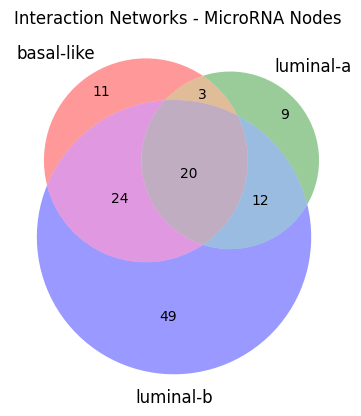

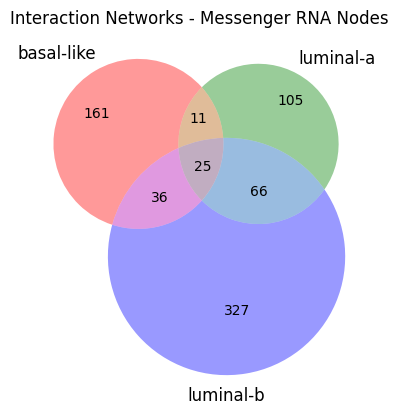

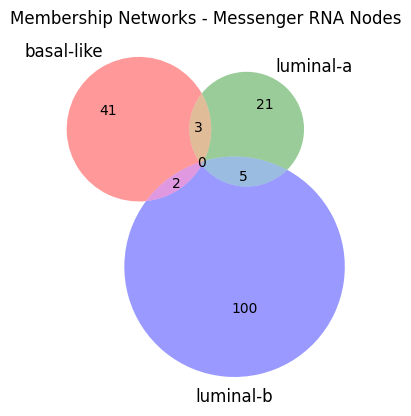

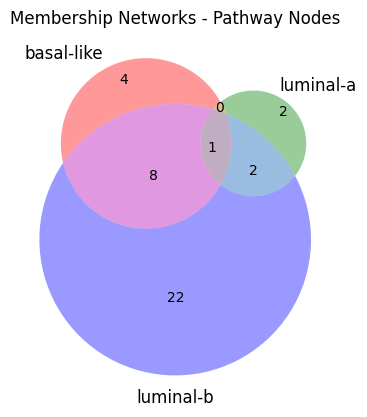

In [17]:
# Plot the Venn diagrams of the network nodes
node_sets = plot_nodes_venn_diagram(cancer_networks)

### Intersections

In [18]:
# Print the resulting nodes from the intersection between the sets
print_resulting_nodes(node_sets, operation='intersection')

===== Interaction Networks - MicroRNA Nodes =====

##### 3-Set Intersections #####

> basal-like ∩ luminal-a ∩ luminal-b = 20
['hsa-miR-106b-5p']
['hsa-miR-130b-3p']
['hsa-miR-141-3p']
['hsa-miR-148a-3p']
['hsa-miR-15b-5p']
['hsa-miR-17-5p']
['hsa-miR-18a-5p']
['hsa-miR-193b-3p']
['hsa-miR-196a-5p']
['hsa-miR-200a-3p']
['hsa-miR-200b-3p']
['hsa-miR-200c-3p']
['hsa-miR-24-3p']
['hsa-miR-27a-3p']
['hsa-miR-29b-3p']
['hsa-miR-30d-5p']
['hsa-miR-33a-5p']
['hsa-miR-33b-5p']
['hsa-miR-429']
['hsa-miR-96-5p']

##### 2-Set Intersections #####

> basal-like ∩ luminal-a = 23
['hsa-let-7c-5p']
['hsa-miR-106b-5p']
['hsa-miR-130b-3p']
['hsa-miR-141-3p']
['hsa-miR-148a-3p']
['hsa-miR-15b-5p']
['hsa-miR-17-5p']
['hsa-miR-18a-5p']
['hsa-miR-193b-3p']
['hsa-miR-196a-5p']
['hsa-miR-200a-3p']
['hsa-miR-200b-3p']
['hsa-miR-200c-3p']
['hsa-miR-20a-5p']
['hsa-miR-24-3p']
['hsa-miR-27a-3p']
['hsa-miR-29b-3p']
['hsa-miR-30d-5p']
['hsa-miR-33a-5p']
['hsa-miR-33b-5p']
['hsa-miR-429']
['hsa-miR-92a-3p']
['hsa-mi

### Differences

In [19]:
# Print the resulting nodes from the difference between the sets
print_resulting_nodes(node_sets, operation='difference')

===== Interaction Networks - MicroRNA Nodes =====

##### 3-Set Differences #####

> basal-like - (luminal-a ∪ luminal-b) = 11
['hsa-let-7e-5p']
['hsa-miR-191-5p']
['hsa-miR-194-5p']
['hsa-miR-19a-3p']
['hsa-miR-21-5p']
['hsa-miR-224-5p']
['hsa-miR-330-5p']
['hsa-miR-335-5p']
['hsa-miR-424-5p']
['hsa-miR-497-5p']
['hsa-miR-93-5p']

> luminal-a - (basal-like ∪ luminal-b) = 9
['hsa-miR-149-5p']
['hsa-miR-181d-5p']
['hsa-miR-192-5p']
['hsa-miR-210-3p']
['hsa-miR-324-5p']
['hsa-miR-365a-3p']
['hsa-miR-365b-3p']
['hsa-miR-425-5p']
['hsa-miR-744-5p']

> luminal-b - (basal-like ∪ luminal-a) = 49
['hsa-let-7b-5p']
['hsa-let-7f-5p']
['hsa-let-7i-5p']
['hsa-miR-1271-5p']
['hsa-miR-134-5p']
['hsa-miR-140-5p']
['hsa-miR-142-5p']
['hsa-miR-143-3p']
['hsa-miR-144-3p']
['hsa-miR-146b-5p']
['hsa-miR-15a-5p']
['hsa-miR-181b-5p']
['hsa-miR-185-5p']
['hsa-miR-186-5p']
['hsa-miR-199a-5p']
['hsa-miR-212-3p']
['hsa-miR-223-3p']
['hsa-miR-23b-3p']
['hsa-miR-26a-5p']
['hsa-miR-27b-3p']
['hsa-miR-299-5p']
['hsa

## Sets of Edges

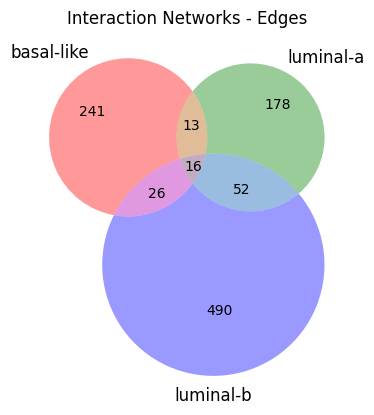

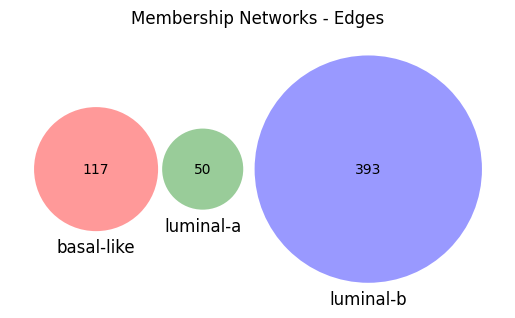

In [20]:
# Plot the Venn diagrams of the network edges
edge_sets = plot_edges_venn_diagram(cancer_networks)

### Intersections

In [21]:
# Print the resulting edges from the intersection between the sets
print_resulting_edges(edge_sets, operation='intersection')

===== Interaction Networks - Edges =====

##### 3-Set Intersections #####

> basal-like ∩ luminal-a ∩ luminal-b = 16
['hsa-miR-106b-5p', 'RASGRF2']
['hsa-miR-141-3p', 'WIPF1']
['hsa-miR-18a-5p', 'ZBTB4']
['hsa-miR-200b-3p', 'ETS1']
['hsa-miR-200b-3p', 'WIPF1']
['hsa-miR-200c-3p', 'FSTL1']
['hsa-miR-200c-3p', 'MAF']
['hsa-miR-29b-3p', 'FKBP14']
['hsa-miR-29b-3p', 'NREP']
['hsa-miR-96-5p', 'ANTXR2']
['hsa-miR-96-5p', 'ARL4C']
['hsa-miR-96-5p', 'BACH2']
['hsa-miR-96-5p', 'CELF2']
['hsa-miR-96-5p', 'DAB2']
['hsa-miR-96-5p', 'FOXO1']
['hsa-miR-96-5p', 'LMOD1']

##### 2-Set Intersections #####

> basal-like ∩ luminal-a = 29
['hsa-miR-106b-5p', 'RASGRF2']
['hsa-miR-141-3p', 'WIPF1']
['hsa-miR-18a-5p', 'ZBTB4']
['hsa-miR-200b-3p', 'ETS1']
['hsa-miR-200b-3p', 'FLI1']
['hsa-miR-200b-3p', 'RUNX1T1']
['hsa-miR-200b-3p', 'WIPF1']
['hsa-miR-200b-3p', 'ZEB1']
['hsa-miR-200c-3p', 'FSTL1']
['hsa-miR-200c-3p', 'MAF']
['hsa-miR-29b-3p', 'FKBP14']
['hsa-miR-29b-3p', 'GPX7']
['hsa-miR-29b-3p', 'NREP']
['hs

### Differences

In [22]:
# Print the resulting edges from the difference between the sets
print_resulting_edges(edge_sets, operation='difference')

===== Interaction Networks - Edges =====

##### 3-Set Differences #####

> basal-like - (luminal-a ∪ luminal-b) = 241
['hsa-let-7c-5p', 'EIF2S2']
['hsa-let-7c-5p', 'IGF1R']
['hsa-let-7d-5p', 'ITSN1']
['hsa-let-7e-5p', 'CD200R1']
['hsa-let-7e-5p', 'CD86']
['hsa-let-7e-5p', 'P2RX1']
['hsa-let-7e-5p', 'SLC5A6']
['hsa-let-7g-5p', 'ACER3']
['hsa-let-7g-5p', 'FAM104A']
['hsa-miR-106a-5p', 'AFF1']
['hsa-miR-106a-5p', 'ARHGEF3']
['hsa-miR-106a-5p', 'ATXN1']
['hsa-miR-106a-5p', 'CYBRD1']
['hsa-miR-106a-5p', 'DAZAP2']
['hsa-miR-106a-5p', 'FNDC3A']
['hsa-miR-106a-5p', 'FYCO1']
['hsa-miR-106a-5p', 'LRCH1']
['hsa-miR-106a-5p', 'NHLRC3']
['hsa-miR-106a-5p', 'PRRG1']
['hsa-miR-106a-5p', 'RASGRF2']
['hsa-miR-106a-5p', 'RBL2']
['hsa-miR-106a-5p', 'SESN3']
['hsa-miR-106a-5p', 'TMEM50B']
['hsa-miR-106a-5p', 'ZNF25']
['hsa-miR-106a-5p', 'ZNF385A']
['hsa-miR-106a-5p', 'ZNFX1']
['hsa-miR-106b-5p', 'BNC2']
['hsa-miR-106b-5p', 'CAMTA2']
['hsa-miR-106b-5p', 'CORO2B']
['hsa-miR-106b-5p', 'CXCL14']
['hsa-miR-106

## Node Classification

In [23]:
# Print the classification of the nodes according to the metric values
print_node_classification(cancer_networks)

===== Interaction Networks - MicroRNA Nodes =====

##### Betweenness Centrality - Descending Ranking #####

> specific = 14
- hsa-miR-130b-3p: ['luminal-b']
- hsa-miR-148a-3p: ['luminal-b']
- hsa-miR-15b-5p: ['luminal-b']
- hsa-miR-182-5p: ['basal-like']
- hsa-miR-193b-3p: ['luminal-b']
- hsa-miR-24-3p: ['luminal-b']
- hsa-miR-27b-3p: ['luminal-b']
- hsa-miR-29a-3p: ['luminal-b']
- hsa-miR-29c-3p: ['luminal-b']
- hsa-miR-301a-3p: ['luminal-a']
- hsa-miR-30b-5p: ['luminal-b']
- hsa-miR-33a-5p: ['luminal-b']
- hsa-miR-34a-5p: ['luminal-b']
- hsa-miR-98-5p: ['luminal-b']

> non_specific = 9
- hsa-miR-106a-5p: ['basal-like', 'luminal-b']
- hsa-miR-106b-5p: ['basal-like', 'luminal-a', 'luminal-b']
- hsa-miR-141-3p: ['basal-like', 'luminal-a', 'luminal-b']
- hsa-miR-18a-5p: ['basal-like', 'luminal-b']
- hsa-miR-200b-3p: ['basal-like', 'luminal-a']
- hsa-miR-200c-3p: ['basal-like', 'luminal-b']
- hsa-miR-25-3p: ['basal-like', 'luminal-b']
- hsa-miR-29b-3p: ['luminal-a', 'luminal-b']
- hsa-miR

## Pairwise Metric Relationships

### Interaction Networks

In [24]:
# Define the network type
network_type = 'interaction'

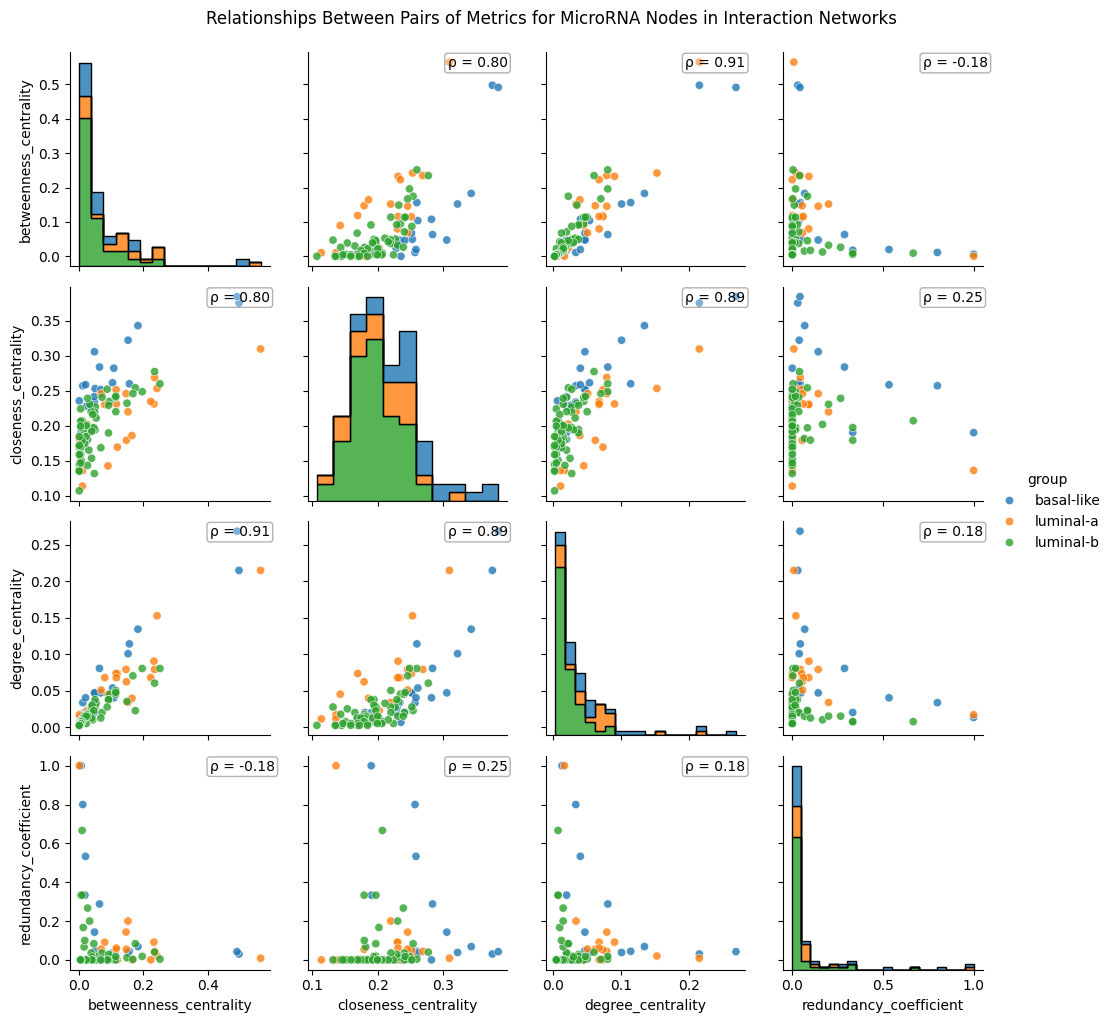

In [25]:
# Plot the histograms of the metric values ​​of the specific partition
plot_pairwise_grid(
    analyzed_networks=cancer_networks, 
    network_type=network_type, 
    partition='MicroRNA', 
)

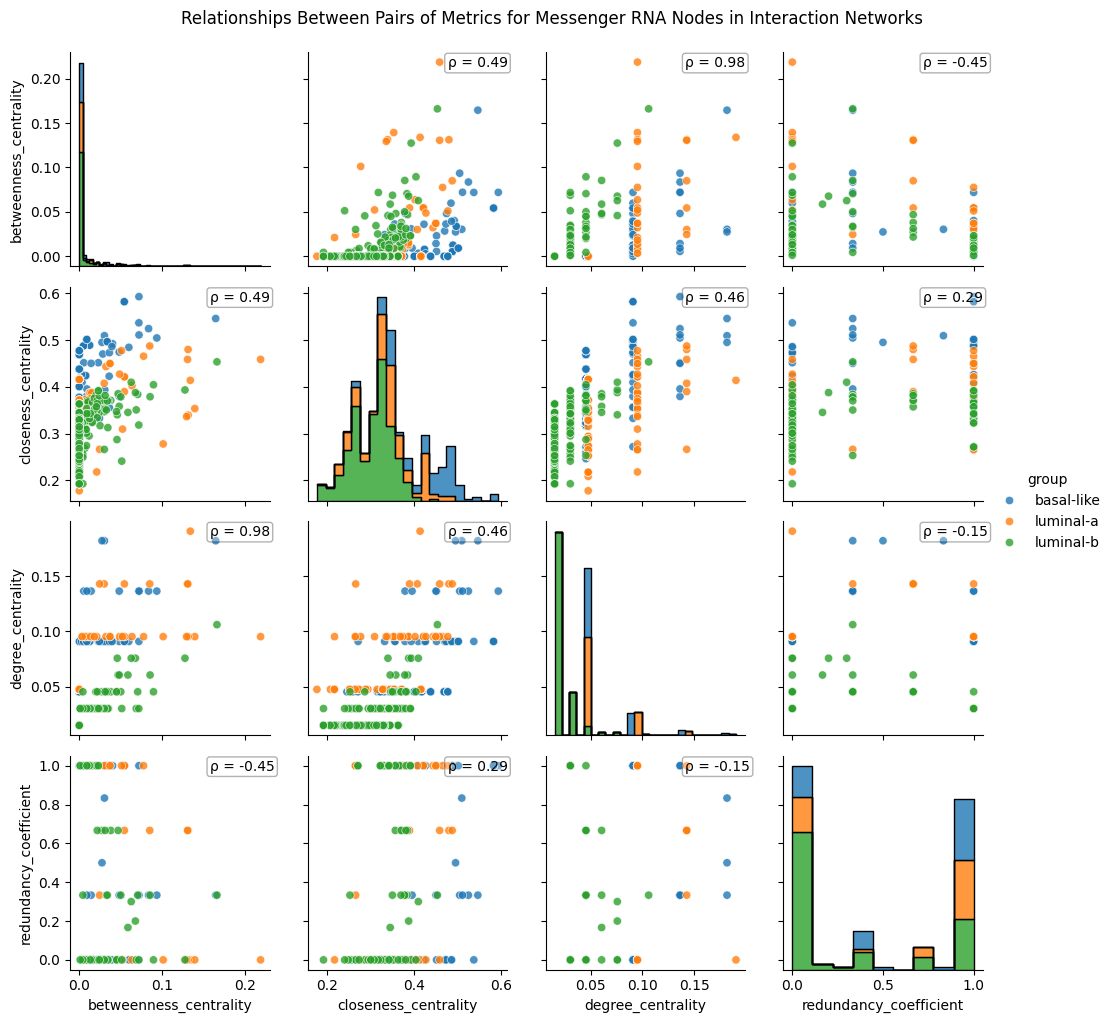

In [26]:
# Plot the histograms of the metric values ​​of the specific partition
plot_pairwise_grid(
    analyzed_networks=cancer_networks, 
    network_type=network_type, 
    partition='Messenger RNA', 
)

### Membership Networks

In [27]:
# Define the network type
network_type = 'membership'

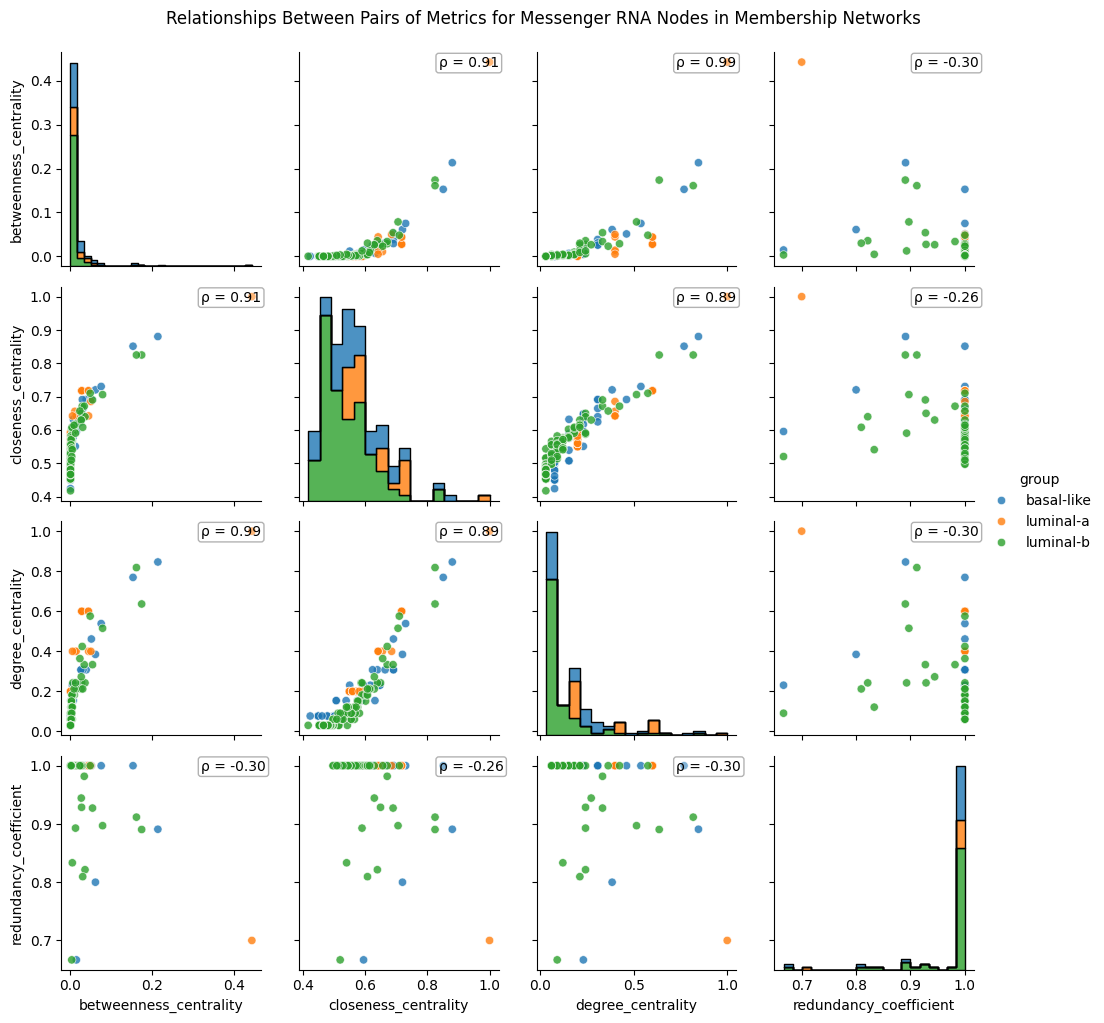

In [28]:
# Plot the grid of pairwise metric relationships
plot_pairwise_grid(
    analyzed_networks=cancer_networks, 
    network_type=network_type, 
    partition='Messenger RNA', 
)

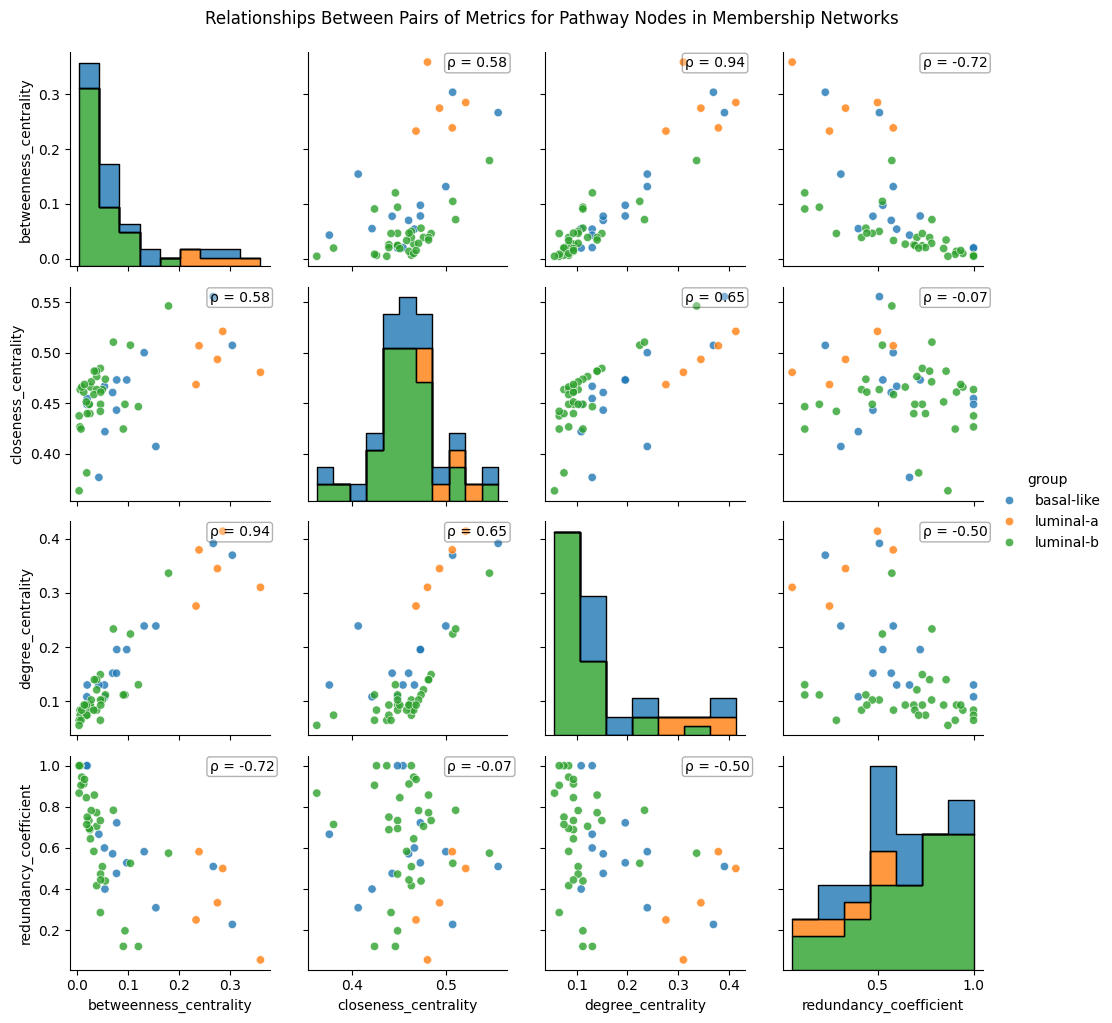

In [29]:
# Plot the grid of pairwise metric relationships
plot_pairwise_grid(
    analyzed_networks=cancer_networks, 
    network_type=network_type, 
    partition='Pathway', 
)

# Cancer vs Normal

## Data Preparation

In [30]:
# Create a dictionary to store abstracted data about cancer
abstracted_networks = dict()

# Iterate over the network types
for network_type in NETWORK_TYPES:
    # Initialize the network type dictionary
    abstracted_networks[network_type] = dict()

    # Iterate over the network elements
    for element in ['edges', 'nodes']:
        # Rename the group column
        df_elements =  \
            analyzed_networks[network_type][element] \
            .rename(columns={'group': 'detailed_group'})
        
        # Abstract the molecular subtype from cancer groups
        df_elements['group'] = np.where(
            df_elements['detailed_group'] != 'normal', 
            'cancer', 'normal'
        )

        # Store the abstracted DataFrame in the dictionary
        abstracted_networks[network_type][element] = \
            df_elements.copy()

## Sets of Nodes

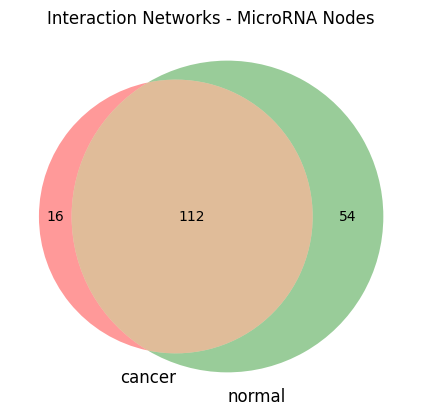

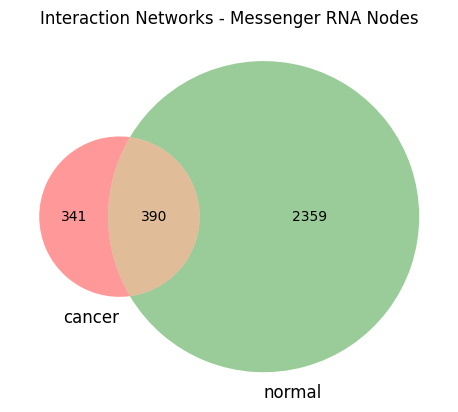

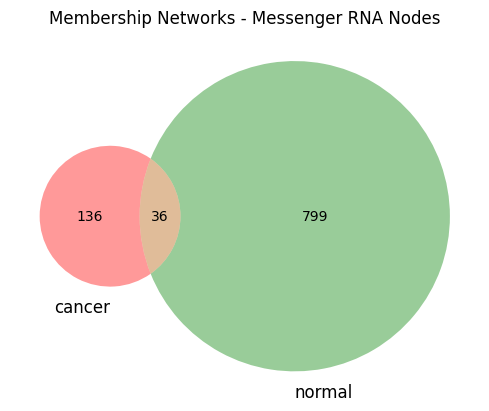

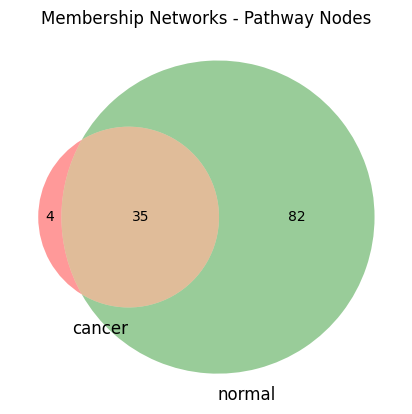

In [31]:
# Plot the Venn diagrams of the network nodes
node_sets = plot_nodes_venn_diagram(abstracted_networks)

#### Intersections

In [32]:
# Print the resulting nodes from the intersection between the sets
print_resulting_nodes(node_sets, operation='intersection')

===== Interaction Networks - MicroRNA Nodes =====

##### 2-Set Intersections #####

> cancer ∩ normal = 112
['hsa-let-7b-5p']
['hsa-let-7c-5p']
['hsa-let-7d-5p']
['hsa-let-7e-5p']
['hsa-let-7f-5p']
['hsa-let-7g-5p']
['hsa-let-7i-5p']
['hsa-miR-106a-5p']
['hsa-miR-106b-5p']
['hsa-miR-107']
['hsa-miR-125b-5p']
['hsa-miR-1271-5p']
['hsa-miR-128-3p']
['hsa-miR-130b-3p']
['hsa-miR-135b-5p']
['hsa-miR-140-5p']
['hsa-miR-141-3p']
['hsa-miR-142-5p']
['hsa-miR-143-3p']
['hsa-miR-144-3p']
['hsa-miR-146b-5p']
['hsa-miR-148a-3p']
['hsa-miR-148b-3p']
['hsa-miR-150-5p']
['hsa-miR-15a-5p']
['hsa-miR-15b-5p']
['hsa-miR-16-5p']
['hsa-miR-17-5p']
['hsa-miR-181b-5p']
['hsa-miR-181d-5p']
['hsa-miR-182-5p']
['hsa-miR-185-5p']
['hsa-miR-186-5p']
['hsa-miR-18a-5p']
['hsa-miR-193a-3p']
['hsa-miR-193b-3p']
['hsa-miR-195-5p']
['hsa-miR-196a-5p']
['hsa-miR-199a-5p']
['hsa-miR-19b-3p']
['hsa-miR-200a-3p']
['hsa-miR-200b-3p']
['hsa-miR-200c-3p']
['hsa-miR-205-5p']
['hsa-miR-20a-5p']
['hsa-miR-20b-5p']
['hsa-miR-21

#### Differences

In [33]:
# Print the resulting nodes from the difference between the sets
print_resulting_nodes(node_sets, operation='difference')

===== Interaction Networks - MicroRNA Nodes =====

##### 2-Set Differences #####

> cancer - normal = 16
['hsa-miR-134-5p']
['hsa-miR-146a-5p']
['hsa-miR-149-5p']
['hsa-miR-151a-3p']
['hsa-miR-155-5p']
['hsa-miR-191-5p']
['hsa-miR-192-5p']
['hsa-miR-194-5p']
['hsa-miR-19a-3p']
['hsa-miR-210-3p']
['hsa-miR-27b-3p']
['hsa-miR-379-5p']
['hsa-miR-449a']
['hsa-miR-590-5p']
['hsa-miR-744-5p']
['hsa-miR-92a-3p']

> normal - cancer = 54
['hsa-let-7a-5p']
['hsa-miR-1-3p']
['hsa-miR-100-5p']
['hsa-miR-103a-3p']
['hsa-miR-10a-5p']
['hsa-miR-125a-5p']
['hsa-miR-129-5p']
['hsa-miR-1306-5p']
['hsa-miR-130a-3p']
['hsa-miR-132-3p']
['hsa-miR-135a-5p']
['hsa-miR-136-5p']
['hsa-miR-139-5p']
['hsa-miR-145-5p']
['hsa-miR-152-3p']
['hsa-miR-154-5p']
['hsa-miR-181a-5p']
['hsa-miR-181c-5p']
['hsa-miR-184']
['hsa-miR-187-3p']
['hsa-miR-190a-5p']
['hsa-miR-193a-5p']
['hsa-miR-196b-5p']
['hsa-miR-199a-3p']
['hsa-miR-199b-3p']
['hsa-miR-204-5p']
['hsa-miR-215-5p']
['hsa-miR-22-5p']
['hsa-miR-28-5p']
['hsa-miR-31

## Sets of Edges

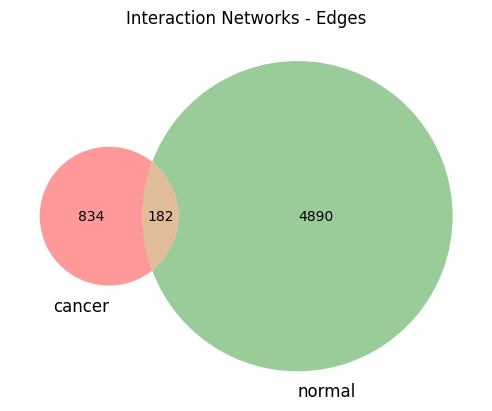

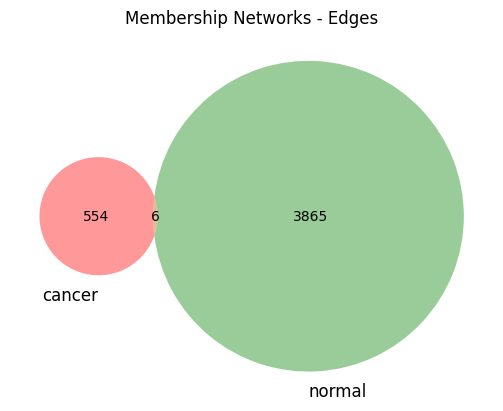

In [34]:
# Plot the Venn diagrams of the network edges
edge_sets = plot_edges_venn_diagram(abstracted_networks)

#### Intersections

In [35]:
# Print the resulting edges from the intersection between the sets
print_resulting_edges(edge_sets, operation='intersection')

===== Interaction Networks - Edges =====

##### 2-Set Intersections #####

> cancer ∩ normal = 182
['hsa-let-7d-5p', 'CPEB4']
['hsa-let-7d-5p', 'PDE12']
['hsa-let-7g-5p', 'BZW1']
['hsa-miR-106a-5p', 'ARHGEF3']
['hsa-miR-106a-5p', 'ATXN1']
['hsa-miR-106a-5p', 'EFCAB14']
['hsa-miR-106a-5p', 'FNDC3A']
['hsa-miR-106a-5p', 'TMEM50B']
['hsa-miR-106b-5p', 'AAK1']
['hsa-miR-106b-5p', 'ESR1']
['hsa-miR-106b-5p', 'IL6ST']
['hsa-miR-106b-5p', 'NBEAL1']
['hsa-miR-106b-5p', 'PURA']
['hsa-miR-106b-5p', 'SMIM14']
['hsa-miR-106b-5p', 'ZBTB20']
['hsa-miR-107', 'GALNT7']
['hsa-miR-130b-3p', 'ESR1']
['hsa-miR-141-3p', 'FOXN3']
['hsa-miR-141-3p', 'NRP1']
['hsa-miR-141-3p', 'PEAK1']
['hsa-miR-141-3p', 'PLXNA4']
['hsa-miR-141-3p', 'QKI']
['hsa-miR-141-3p', 'SOX17']
['hsa-miR-141-3p', 'TRHDE']
['hsa-miR-141-3p', 'WIPF1']
['hsa-miR-142-5p', 'SMAD5']
['hsa-miR-146b-5p', 'BTG2']
['hsa-miR-148a-3p', 'DOCK6']
['hsa-miR-148a-3p', 'RTN4']
['hsa-miR-148a-3p', 'RXRA']
['hsa-miR-16-5p', 'ACVR2A']
['hsa-miR-16-5p', 'AN

#### Differences

In [36]:
# Print the resulting edges from the difference between the sets
print_resulting_edges(edge_sets, operation='difference')

===== Interaction Networks - Edges =====

##### 2-Set Differences #####

> cancer - normal = 834
['hsa-let-7b-5p', 'PEG10']
['hsa-let-7b-5p', 'SENP5']
['hsa-let-7c-5p', 'EIF2S2']
['hsa-let-7c-5p', 'IGF1R']
['hsa-let-7c-5p', 'PARD6B']
['hsa-let-7d-5p', 'CALU']
['hsa-let-7d-5p', 'CSRNP3']
['hsa-let-7d-5p', 'ITSN1']
['hsa-let-7e-5p', 'CD200R1']
['hsa-let-7e-5p', 'CD86']
['hsa-let-7e-5p', 'P2RX1']
['hsa-let-7e-5p', 'SLC5A6']
['hsa-let-7f-5p', 'TMEM251']
['hsa-let-7g-5p', 'ACER2']
['hsa-let-7g-5p', 'ACER3']
['hsa-let-7g-5p', 'AFF2']
['hsa-let-7g-5p', 'FAM104A']
['hsa-let-7g-5p', 'KCTD10']
['hsa-let-7g-5p', 'KLHL13']
['hsa-let-7g-5p', 'PAWR']
['hsa-let-7g-5p', 'POLR3D']
['hsa-let-7g-5p', 'PRLR']
['hsa-let-7g-5p', 'SMARCAD1']
['hsa-let-7g-5p', 'STX17']
['hsa-let-7g-5p', 'TMEM251']
['hsa-let-7i-5p', 'CPEB4']
['hsa-let-7i-5p', 'FNIP1']
['hsa-let-7i-5p', 'MSI2']
['hsa-miR-106a-5p', 'AFF1']
['hsa-miR-106a-5p', 'CYBRD1']
['hsa-miR-106a-5p', 'DAZAP2']
['hsa-miR-106a-5p', 'FOXF1']
['hsa-miR-106a-5p'

## Node Classification

In [37]:
# Print the classification of the nodes according to the metric values
print_node_classification(abstracted_networks)

===== Interaction Networks - MicroRNA Nodes =====

##### Betweenness Centrality - Descending Ranking #####

> specific = 32
- hsa-let-7b-5p: ['normal']
- hsa-let-7e-5p: ['normal']
- hsa-miR-107: ['normal']
- hsa-miR-139-5p: ['normal']
- hsa-miR-145-5p: ['normal']
- hsa-miR-152-3p: ['normal']
- hsa-miR-15a-5p: ['normal']
- hsa-miR-185-5p: ['normal']
- hsa-miR-186-5p: ['normal']
- hsa-miR-193a-5p: ['normal']
- hsa-miR-195-5p: ['normal']
- hsa-miR-20b-5p: ['normal']
- hsa-miR-22-3p: ['normal']
- hsa-miR-223-3p: ['normal']
- hsa-miR-224-5p: ['normal']
- hsa-miR-27b-3p: ['cancer']
- hsa-miR-30b-5p: ['cancer']
- hsa-miR-30c-5p: ['normal']
- hsa-miR-30e-5p: ['normal']
- hsa-miR-326: ['normal']
- hsa-miR-33a-5p: ['cancer']
- hsa-miR-33b-5p: ['cancer']
- hsa-miR-342-3p: ['cancer']
- hsa-miR-34a-5p: ['cancer']
- hsa-miR-363-3p: ['normal']
- hsa-miR-378a-3p: ['normal']
- hsa-miR-378c: ['normal']
- hsa-miR-452-5p: ['normal']
- hsa-miR-454-3p: ['normal']
- hsa-miR-486-5p: ['normal']
- hsa-miR-532-3

## Pairwise Metric Relationships

### Interaction Networks

In [38]:
# Define the network type
network_type = 'interaction'

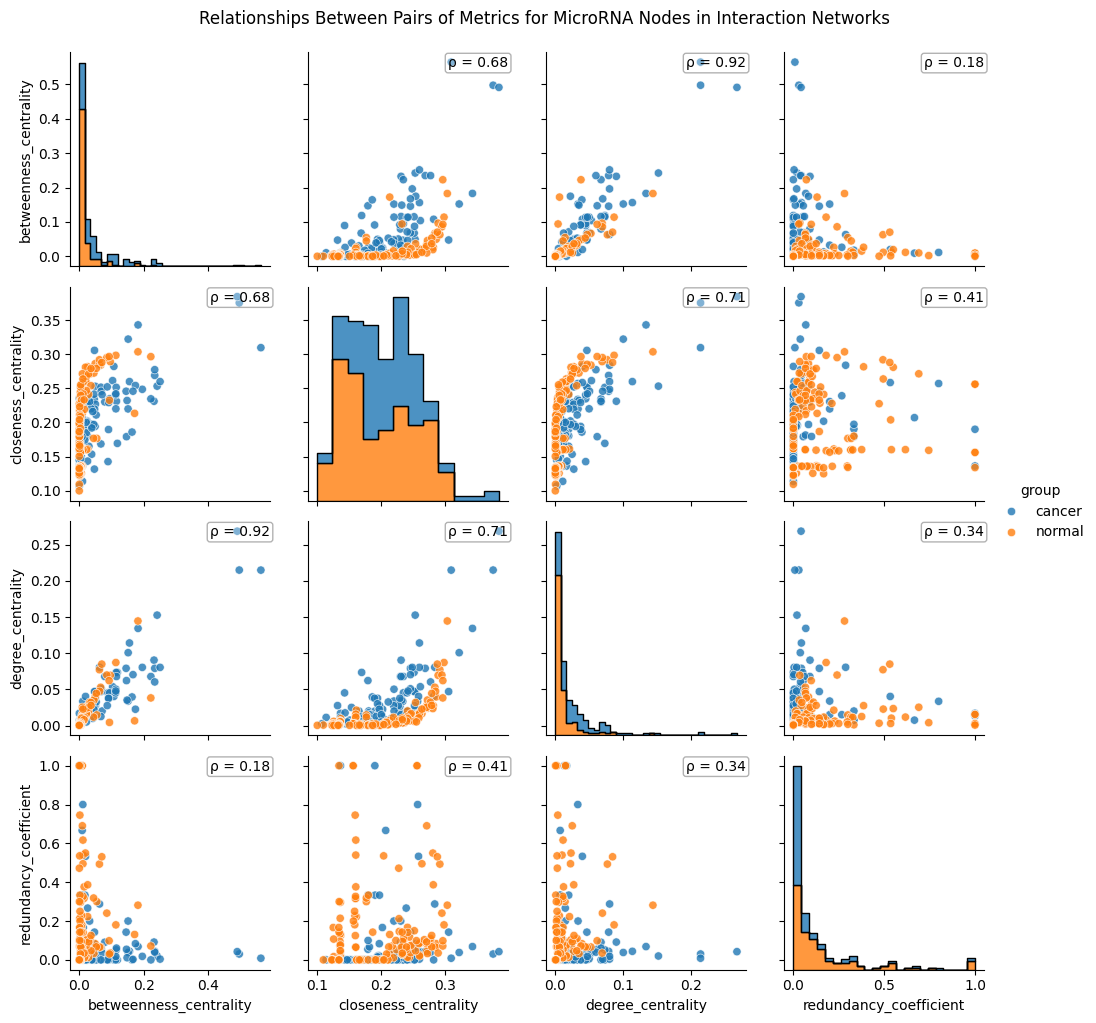

In [39]:
# Plot the grid of pairwise metric relationships
plot_pairwise_grid(
    analyzed_networks=abstracted_networks, 
    network_type=network_type,  
    partition='MicroRNA', 
)

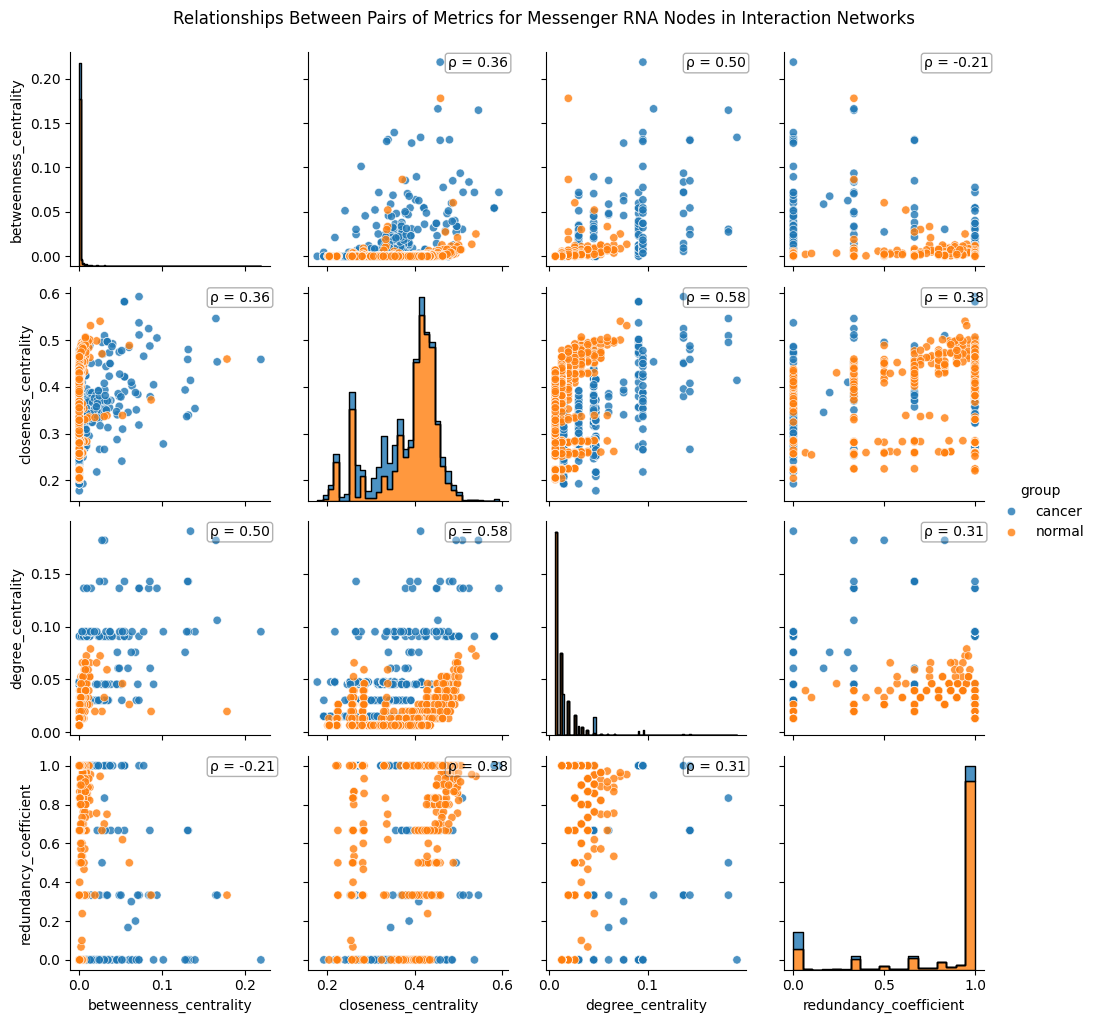

In [40]:
# Plot the grid of pairwise metric relationships
plot_pairwise_grid(
    analyzed_networks=abstracted_networks, 
    network_type=network_type, 
    partition='Messenger RNA', 
)

### Membership Networks

In [41]:
# Define the network type
network_type = 'membership'

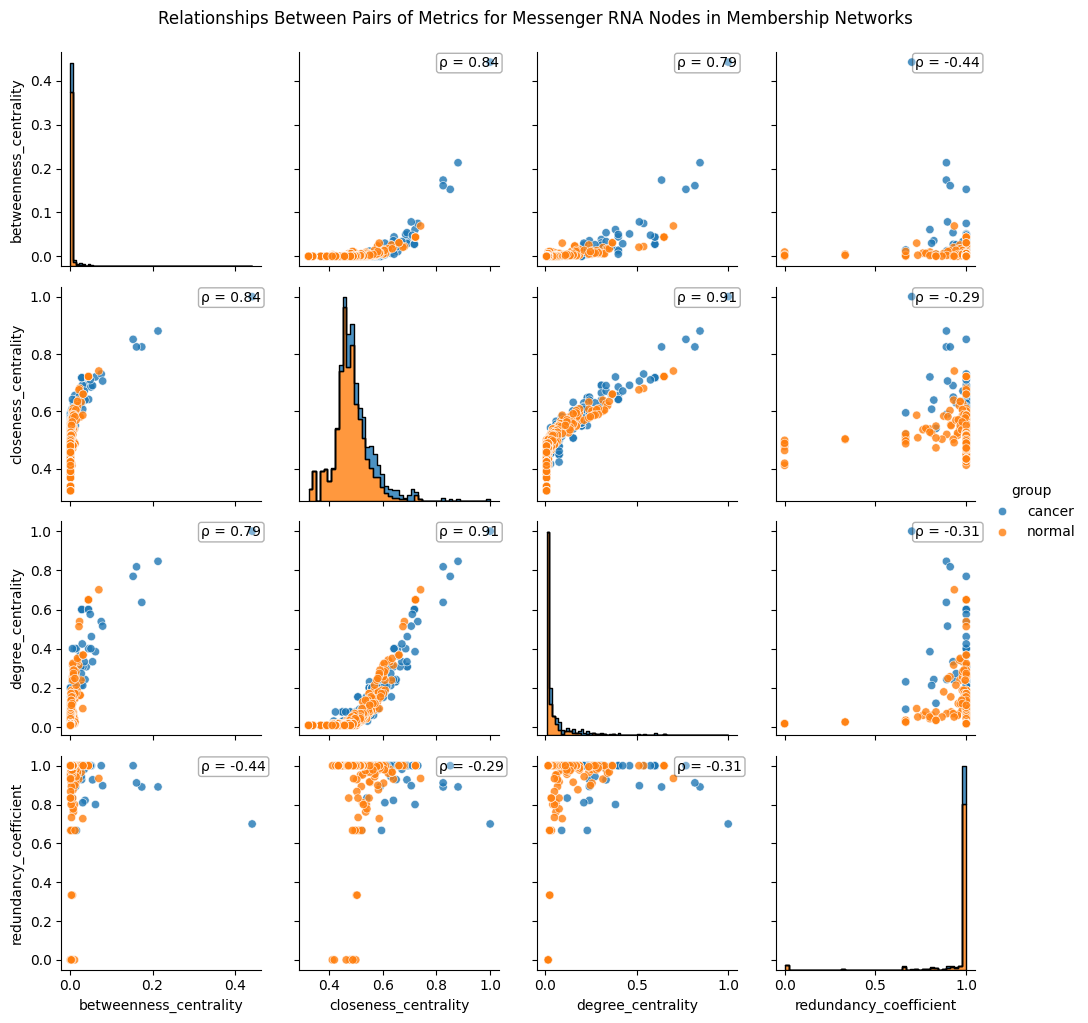

In [42]:
# Plot the grid of pairwise metric relationships
plot_pairwise_grid(
    analyzed_networks=abstracted_networks, 
    network_type=network_type, 
    partition='Messenger RNA', 
)

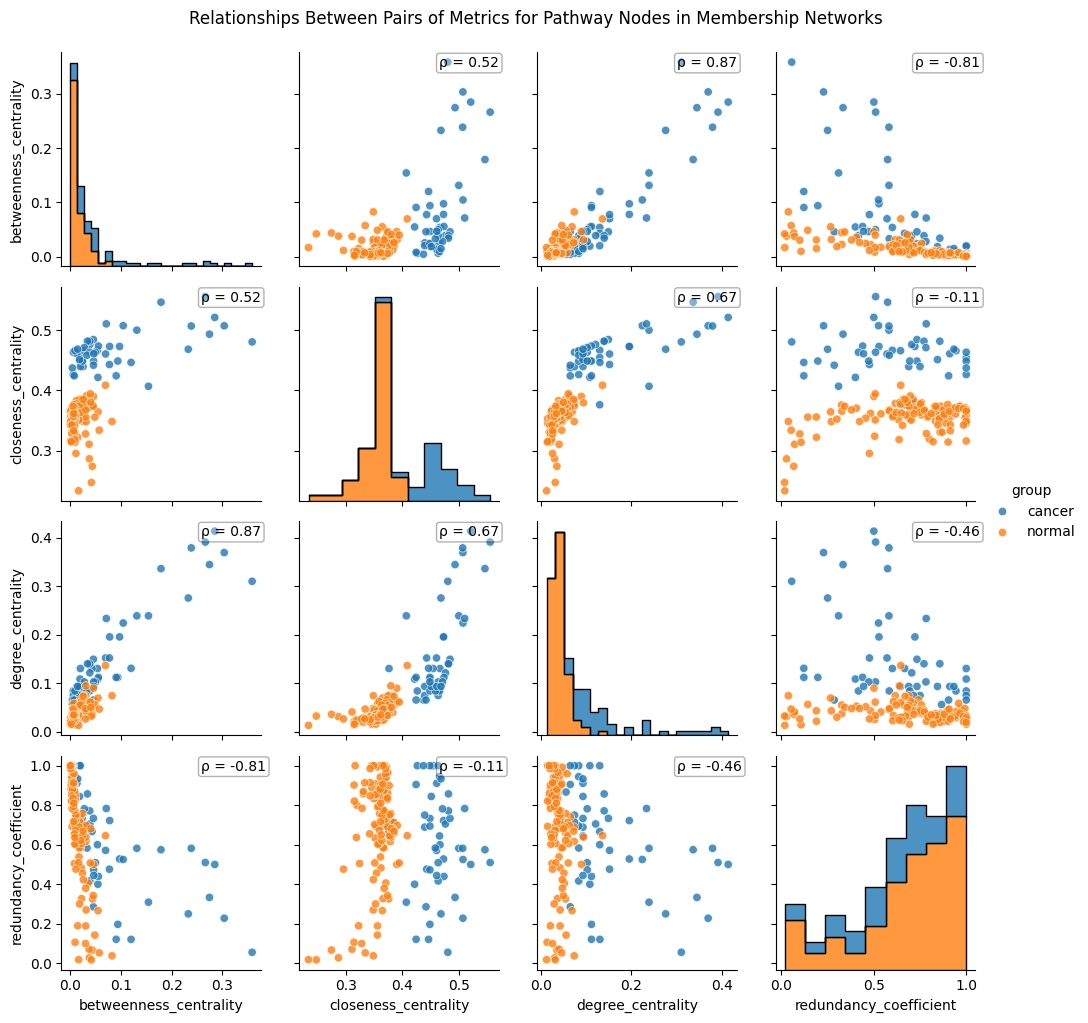

In [43]:
# Plot the grid of pairwise metric relationships
plot_pairwise_grid(
    analyzed_networks=abstracted_networks, 
    network_type=network_type, 
    partition='Pathway', 
)